# DFXM rocking-curve reconstruction — a tutorial (1D & 2D)

**What this notebook does.** You have a *rocking-curve pattern set*: a stack of DFXM detector
images taken while rocking the sample through the Bragg condition, in **one** angle (1D) or
**two** (2D, a mosaicity scan). This notebook simulates such a set from a sample with a *known*
orientation field, then **reconstructs** it, and checks the answer against ground truth.

Everything runs on `midas_dfxm` — no re-implementation. The thing you must get right for real
data — **the convention: scattering-plane orientation, lab frame, and detector flips** — is a
single config block at the top that every cell reads.

**The idea in one line.** A rocking scan measures, *per detector pixel*, an intensity-vs-angle
curve. Its **peak position** is the local lattice tilt (orientation); its **width** is the
local mosaic spread (after deconvolving the instrument). 1D gives one tilt component; 2D gives
both, and reveals the strongly **anisotropic** acceptance (rock ≪ roll).

**Sections:** 0 Config · 1 Geometry · 2 Phantom · 3 Simulate 1D · 4 Reconstruct 1D ·
5 Simulate 2D · 6 Reconstruct 2D · 7 Convention & flip robustness · 8 Real data.


## 0. Configuration — conventions and detector flips

**Change these and re-run.** The choices that trip people up on real data live here:

- **Scattering geometry** — which plane `k, k', Q` live in. `"vertical"` = ESRF ID06-HXM
  (diffraction plane x–z). `"horizontal"` = APS 6-ID-C transmission (x–y). This sets the rock
  axis, the detector basis, and the resolution roles automatically.
- **Lab frame** — which lab axis is the beam / is up (`"midas"`: x-beam/z-up, `"aps"`:
  z-beam/y-up, or a `LabFrame(...)`).
- **Detector flips** — a real detector's rows/cols map to lab `(u, v)` in an orientation you
  must know: `fliplr`, `flipud`, `transpose`. Applied to every frame identically, a flip does
  **not** change any single pixel's rocking curve — but it mirrors/rotates the reconstructed
  **map**, so a wrong flip puts your gradient or grains in the wrong place.


In [1]:
import math, numpy as np, torch
import matplotlib.pyplot as plt
torch.manual_seed(0); DT = torch.float64

CFG = dict(
    geometry       = "VERTICAL_MIDAS",   # a named preset: "VERTICAL_MIDAS" (ESRF ID06),
                                         # "HORIZONTAL_APS" (APS 6-ID-C), "HORIZONTAL_MIDAS",
                                         # or None to build from geometry_plane + lab_frame below
    geometry_plane = "vertical",     # used only if geometry=None: "vertical" | "horizontal"
    lab_frame      = "midas",        # used only if geometry=None: "midas" | "aps" | LabFrame(...)
    detector_flip  = dict(fliplr=False, flipud=False, transpose=False),

    energy_keV     = 20.0,
    lattice        = (3.96, 3.96, 3.96, 90.0, 90.0, 90.0),   # a,b,c,al,be,ga
    hkl            = (1, 1, 1),
    magnification  = 2.5,            # chosen so the detector FOV matches the sample (see below)
    pixel_um       = 0.5,
    detector_shape = (64, 64),
    add_noise      = False,          # main path uses clean intensity; Section 4c adds realism

    slab_shape     = (32, 32, 1),    # (ny,nx,nz); nz=1 -> thin slab, no depth integration
    voxel_um       = 0.4,
    tilt_deg_per_um= 0.03,
    tilt_axis      = "beam",         # "beam"|"outboard"|"up"; a tilt about "up" is ~invisible to rocking!
    subgrain       = True,

    span_1d        = 0.4, n_1d = 61,               # 1D rock span +/- deg, n points
    span_2d        = 0.6, n_2d = 17,               # 2D grid half-span, n per axis (n^2 frames)
)
WAVELENGTH = 12.398419843320026 / CFG["energy_keV"]
fov = CFG["detector_shape"][1]*CFG["pixel_um"]/CFG["magnification"]
print(f"wavelength = {WAVELENGTH:.5f} A ; detector FOV = {fov:.1f} um vs sample "
      f"{CFG['slab_shape'][1]*CFG['voxel_um']:.1f} um  (match these!)")

wavelength = 0.61992 A ; detector FOV = 12.8 um vs sample 12.8 um  (match these!)


## 1. Geometry & conventions — read this before pointing it at your data

Everything downstream — which detector axis maps cleanly to the sample, what a peak shift
*means*, whether the map comes out mirrored — follows from three choices. Set them once in the
config; `ScatteringGeometry` derives the rest.

**1. The lab frame** is fixed by two unit axes, `beam` (incident-beam direction) and `up`
(vertical); `outboard = up × beam` completes a right-handed set. Presets:
- `MIDAS_FRAME` (ESRF / package default): beam = **x**, up = **z**, outboard = **y**.
- `APS_FRAME` (6-ID-C / Park): beam = **Z**, up = **Y**, outboard = **X**.

So "x/y/z" in one lab is not "x/y/z" in the other — **always name the frame** when you quote a
direction.

**2. The scattering plane** holds the incident beam `k`, the diffracted beam `k'`, and `Q`. The
beam bends from `beam` toward a `deflection` axis by `2θ`:
- `plane="vertical"` (ESRF ID06-HXM): deflection = `up` → `k, k', Q` in the beam–up plane.
- `plane="horizontal"` (APS 6-ID-C transmission): deflection = `outboard` → horizontal plane.
  **This is Zahir's 6-ID-C** → use `geometry="HORIZONTAL_APS"`.

From this the code builds `k_out = cos2θ·beam + sin2θ·deflection` (the objective's optical
axis), the **rock axis** = `beam × deflection` (rotating about it changes `θ`, i.e. moves `Q`
*along* the scattering plane), and the **detector `(u, v)`** basis (the image plane, ⊥ `k_out`).

**3. The clean vs collapsed detector axis.** The detector axis that is *out* of the scattering
plane maps 1:1 to the sample (**clean**); the axis *in* the plane mixes the beam direction with
the deflection — the inclined projection collapses them. For 6-ID-C horizontal with crystal
`c‖beam, a‖outboard, b‖up`, the vertical detector axis `v = b` is clean (a (400)-type reflection
images `b‖up` undistorted), while `c`(beam) and `a` collapse onto `u`. §7 shows how to recover
the *total* map orientation — this projection handedness folded together with any detector flip —
against a fiducial.

The cell prints all of these for your geometry and contrasts the other plane (the 90° roll
between ID06 and 6-ID-C).

In [2]:
import midas_dfxm.conventions as _cv
from midas_dfxm.conventions import as_geometry, as_frame, ScatteringGeometry, LabFrame
from midas_dfxm.optics import detector_basis

# a named preset (VERTICAL_MIDAS / HORIZONTAL_APS / HORIZONTAL_MIDAS) wins; else build from plane+frame
if CFG.get("geometry"):
    GEOM = getattr(_cv, CFG["geometry"]) if isinstance(CFG["geometry"], str) else CFG["geometry"]
else:
    GEOM = ScatteringGeometry(frame=as_frame(CFG["lab_frame"]), plane=CFG["geometry_plane"])
FRAME = GEOM.frame

def geom_report(g, tt=20.0):
    k = g.k_out(tt); u, v = detector_basis(k, geometry=g)
    r3 = lambda t: tuple(round(float(x),3) for x in t)
    print(f"  frame     beam={r3(g.beam_direction())} up={g.frame.up} outboard={r3(torch.tensor(g.frame.outboard))}")
    print(f"  plane     {g.plane:10s} deflection={r3(g.deflection_direction())}")
    print(f"  rock axis {r3(g.plane_normal())}   detector u={r3(u)}  v={r3(v)}")

print("YOUR geometry:", CFG.get("geometry") or f"{CFG['geometry_plane']}/{CFG['lab_frame']}",
      "| plane", GEOM.plane, "| beam", GEOM.frame.beam, "up", GEOM.frame.up); geom_report(GEOM)
print("other plane:"); geom_report(ScatteringGeometry(frame=FRAME,
      plane="horizontal" if CFG["geometry_plane"]=="vertical" else "vertical"))

YOUR geometry: VERTICAL_MIDAS | plane vertical | beam (1.0, 0.0, 0.0) up (0.0, 0.0, 1.0)
  frame     beam=(1.0, 0.0, 0.0) up=(0.0, 0.0, 1.0) outboard=(0.0, 1.0, 0.0)
  plane     vertical   deflection=(0.0, 0.0, 1.0)
  rock axis (0.0, -1.0, 0.0)   detector u=(0.0, 1.0, 0.0)  v=(-0.342, 0.0, 0.94)
other plane:
  frame     beam=(1.0, 0.0, 0.0) up=(0.0, 0.0, 1.0) outboard=(0.0, 1.0, 0.0)
  plane     horizontal deflection=(0.0, 1.0, 0.0)
  rock axis (0.0, 0.0, 1.0)   detector u=(-0.342, 0.94, 0.0)  v=(0.0, -0.0, 1.0)


### 1a. Scan types — what you SWEEP sets what the map MEANS

DFXM builds a map from a stack of images taken while sweeping one or two angles. **Which** angle
you sweep, and whether the detector `2θ` moves with it, decides what the per-pixel peak position
means. Read the sweep from the **motor log, never the filename** — on the NaMnO2 data the
filename step was *half* the true motor step, which would have halved the tilt scale (§7b).

| You sweep… | `2θ` … | scan type | per-pixel **peak position** → | per-pixel **width** → | how to run it |
|---|---|---|---|---|---|
| a sample tilt (`θ` or `χ`) | **fixed** | **mosaic / rocking** | **lattice TILT** (orientation), *one* component | mosaic spread (+ instrument) | §5–6 here; §7b auto-detects |
| `θ` **and** `2θ` together (`2θ = 2θ`) | **moves** (slope 2) | **strain** (θ–2θ) | **d-spacing** → relative strain `ε = −cotθ_B·Δθ` | strain spread | §7b auto-detects (slope ≈ 2) |
| two tilt axes (rock **+** roll) on a grid | **fixed** | **2D mosaicity** | **full 2D orientation** (both tilt components) | anisotropic mosaic covariance (rock ≪ roll) | §5–6 (`mosaicity_scan`) |

Rules of thumb for choosing and configuring a sweep:

- **Pick the scan for the quantity you want.** A single reflection senses a given deformation as
  *either* a lattice tilt (transverse, θ-rock → mosaic) *or* a d-spacing change (longitudinal,
  θ–2θ → strain), set by the reflection direction — not both. Mosaic answers *"which way is the
  lattice tilted here?"* (orientation domains); strain answers *"how is d-spacing stretched
  here?"*
- **Rock vs roll.** The **rock** axis (`GEOM.plane_normal()`, printed above) moves `Q` along the
  scattering plane — it changes `θ` and has the *tight* resolution. The **roll** axis is the
  orthogonal transverse tilt — *wide* resolution. That anisotropy (rock ≪ roll) is real and is
  why §6 calibrates the resolution as an ellipse. A **1D rock** gives one tilt component; a **2D
  rock+roll** grid gives the full 2D orientation.
- **Step size.** Put a few points across the peak: step ≈ ⅓ of the per-pixel FWHM. The NaMnO2
  mosaic scans used 10 mdeg steps over a ~40 mdeg peak (~4 points) — workable but coarse; finer
  sampling tightens the width / intrinsic-mosaic map (the orientation *centroid* is robust even
  when coarse, the *width* is not).
- **Span.** Cover the full tilt (or strain) range across the field of view *plus* a few peak
  widths on each side, so no pixel's peak is truncated at a scan edge.

The §7b reducer applies exactly this logic automatically: it reads the motor log, and if `2θ` is
fixed it reduces as mosaic (peak → tilt), if `2θ` tracks `θ` at slope 2 it reduces as strain
(peak → d-spacing).

### 1b. Detector flips

A flip is a relabelling of the pixel grid. Applied identically to every frame it leaves each
pixel's rocking curve intact — so per-pixel reconstructed values are unchanged — but it
mirrors/rotates the **map**. On real data you fix the flip by matching a known fiducial (a
scratch, the sample edge, a marked grain). One helper, used everywhere:

In [3]:
def apply_detector_flip(x, flip):
    '''x: (M,nu,nv) or (nu,nv). transpose, then flipud/fliplr.'''
    if flip.get("transpose"): x = x.transpose(-2, -1)
    if flip.get("flipud"):    x = torch.flip(x, dims=[-2])
    if flip.get("fliplr"):    x = torch.flip(x, dims=[-1])
    return x

def unflip(x, flip):  # inverse, to view a reconstructed map in sample coordinates
    if flip.get("fliplr"):    x = torch.flip(x, dims=[-1])
    if flip.get("flipud"):    x = torch.flip(x, dims=[-2])
    if flip.get("transpose"): x = x.transpose(-2, -1)
    return x

_t = torch.arange(24, dtype=DT).reshape(2,3,4)
print("flip preserves per-frame intensity:",
      bool(torch.allclose(_t.sum((-1,-2)), apply_detector_flip(_t, dict(fliplr=1,flipud=1,transpose=1)).sum((-1,-2)))))

flip preserves per-frame intensity: True


## 2. A phantom with a *known* orientation field

A thin slab (`nz=1`, so no depth integration to muddy ground truth) carrying a smooth tilt
gradient plus a misoriented sub-grain patch. The magnification is set so the detector images
the whole slab at ≈ voxel resolution.

(hkl)=(1, 1, 1)  |Q|=2.748  2theta=15.58 deg


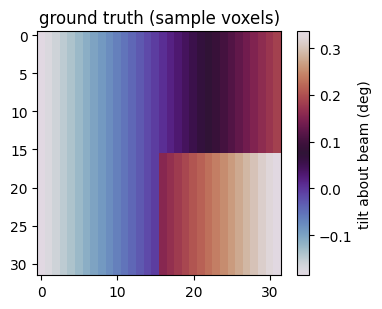

tilt axis = beam: rocking senses tilts about beam/outboard; a tilt about 'up' barely moves the peak (nearly invisible) -- a real DFXM sensitivity, like g.b invisibility.


In [4]:
from midas_dfxm import (make_uniform_field, with_orientation_gradient, reference_q_nom,
    bragg_two_theta_deg, poulsen_aligned_resolution, ObjectiveOptics, GoniometerSetting,
    rocking_scan, mosaicity_scan, scan_angles, dfxm_stack, fit_rocking_curve,
    moment_orientation, detector_model, polar_decomposition)
from midas_dfxm.field import DeformationField

ny, nx, nz = CFG["slab_shape"]
TILT = FRAME.axis(CFG["tilt_axis"]).to(DT)     # rocking senses tilts about beam/outboard; ~blind to "up"
base  = make_uniform_field(shape=CFG["slab_shape"], spacing_um=CFG["voxel_um"],
                           lattice_params=CFG["lattice"], dtype=DT)
field = with_orientation_gradient(base, axis=tuple(float(x) for x in TILT),
                                  deg_per_um=CFG["tilt_deg_per_um"], along=1)
if CFG["subgrain"]:
    F = field.F.clone(); pos = field.positions
    patch = (pos[:,0] > pos[:,0].median()) & (pos[:,1] > pos[:,1].median())
    a = math.radians(0.15)
    K = torch.tensor([[0,-TILT[2],TILT[1]],[TILT[2],0,-TILT[0]],[-TILT[1],TILT[0],0]], dtype=DT)
    Rp = torch.eye(3,dtype=DT) + math.sin(a)*K + (1-math.cos(a))*(K@K)
    F[patch] = Rp @ F[patch]
    field = DeformationField(positions=pos, F=F, reference_orientation=field.reference_orientation,
                             lattice_params=field.lattice_params, shape=field.shape)

center    = GoniometerSetting(frame=FRAME)
q_nom     = reference_q_nom(field, CFG["hkl"], center)
q_mag     = float(torch.linalg.vector_norm(q_nom))
two_theta = bragg_two_theta_deg(q_mag, WAVELENGTH)
res       = poulsen_aligned_resolution(q_nom, two_theta_deg=two_theta, geometry=GEOM)
optics    = ObjectiveOptics(two_theta_deg=two_theta, magnification=CFG["magnification"],
                            pixel_um=CFG["pixel_um"], detector_shape=CFG["detector_shape"], geometry=GEOM)
print(f"(hkl)={CFG['hkl']}  |Q|={q_mag:.3f}  2theta={two_theta:.2f} deg")

def gt_tilt_deg(f):
    R,_ = polar_decomposition(f.F); A = 0.5*(R - R.transpose(-1,-2))
    wv = torch.stack([A[:,2,1], A[:,0,2], A[:,1,0]], -1)
    return torch.rad2deg((wv*TILT).sum(-1))
plt.figure(figsize=(4,3.2)); plt.imshow(gt_tilt_deg(field).reshape(ny,nx).numpy(), cmap="twilight")
plt.colorbar(label=f"tilt about {CFG['tilt_axis']} (deg)"); plt.title("ground truth (sample voxels)"); plt.tight_layout(); plt.show()
print(f"tilt axis = {CFG['tilt_axis']}: rocking senses tilts about beam/outboard; a tilt about 'up' "
      f"barely moves the peak (nearly invisible) -- a real DFXM sensitivity, like g.b invisibility.")

## 3. Simulate a 1D rocking scan

Rock one axis (`chi`) through Bragg; render a detector image per setting → a `(M,nu,nv)` stack;
optionally push through the camera model for 16-bit noise; apply the configured detector flip.

1D stack: (61, 64, 64)


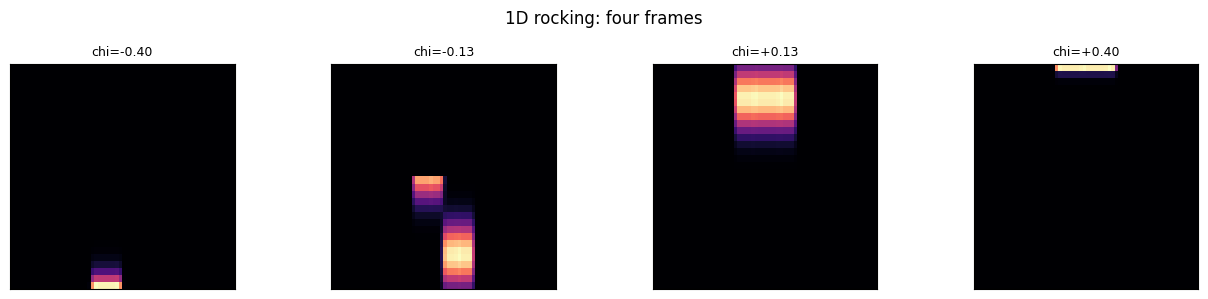

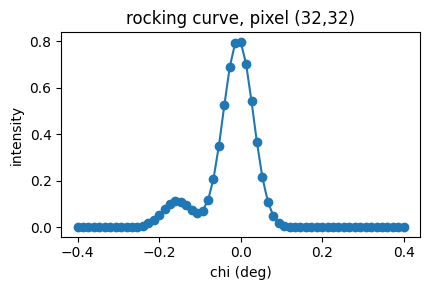

In [5]:
s1  = rocking_scan(center, axis="chi", span=(-CFG["span_1d"], CFG["span_1d"]), n=CFG["n_1d"])
ang = scan_angles(s1, "chi")
def bg_subtract(stack):   # remove each pixel's off-Bragg baseline (a robust dark estimate)
    return (stack - stack.amin(0, keepdim=True)).clamp_min(0)

clean_1d = dfxm_stack(field, CFG["hkl"], s1, res, optics)
if CFG["add_noise"]:
    g = torch.Generator().manual_seed(1)
    obs_1d = bg_subtract(torch.stack([detector_model(fr, noise=True, generator=g).to(DT) for fr in clean_1d]))
else:
    obs_1d = clean_1d
obs_1d = apply_detector_flip(obs_1d, CFG["detector_flip"])
print("1D stack:", tuple(obs_1d.shape))

fig, ax = plt.subplots(1, 4, figsize=(13, 3))
for a, m in zip(ax, np.linspace(0, len(ang)-1, 4).astype(int)):
    a.imshow(obs_1d[m].numpy(), cmap="magma"); a.set_title(f"chi={float(ang[m]):+.2f}", fontsize=9); a.set_xticks([]); a.set_yticks([])
plt.suptitle("1D rocking: four frames"); plt.tight_layout(); plt.show()
py, px = obs_1d.shape[1]//2, obs_1d.shape[2]//2
plt.figure(figsize=(4.4,3)); plt.plot(ang.numpy(), obs_1d[:,py,px].numpy(), "o-")
plt.xlabel("chi (deg)"); plt.ylabel("intensity"); plt.title(f"rocking curve, pixel ({py},{px})"); plt.tight_layout(); plt.show()

## 4. Reconstruct the 1D scan

Per pixel, fit the rocking curve with `fit_rocking_curve` (a pseudo-Voigt). The **center** =
local tilt; the **width** = mosaic spread (instrument + intrinsic). We validate the fit against
the noiseless per-pixel centre-of-mass, and view the tilt map in sample coordinates (un-flipped).

(guard: 2940 no-signal/background pixels -> moment)
fit vs noiseless-centre RMS = 2.4 mdeg over 1154 lit pixels


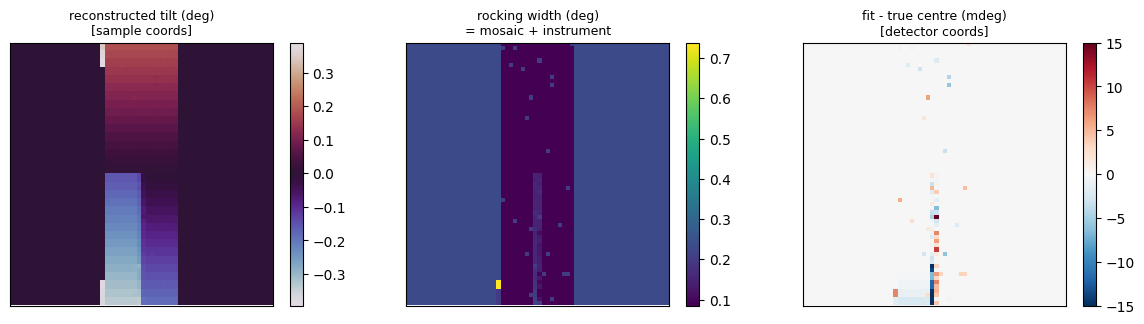

The tilt map is the smooth gradient + sub-grain patch we planted.


In [6]:
M = obs_1d.shape[0]; H, W = obs_1d.shape[1:]
d1 = obs_1d.reshape(M, -1).T.contiguous()
fit = fit_rocking_curve(d1, ang, steps=120, polish=120)
fc = torch.nan_to_num(fit["center"][:,0], nan=0.0, posinf=0.0, neginf=0.0)
# defensive guard: a no-signal (background) pixel has no meaningful centre. The fit now bounds
# the centre to the scanned range, but for such pixels we still prefer the moment. No-op on lit data.
mom1 = (d1.clamp_min(0)*ang).sum(-1) / (d1.clamp_min(0).sum(-1)+1e-30)
bad = fc.abs() >= CFG["span_1d"]
fc = torch.where(bad, mom1, fc)
center_map = fc.reshape(H, W); width_map = fit["width"][:,0].reshape(H, W)
if int(bad.sum()): print(f"(guard: {int(bad.sum())} no-signal/background pixels -> moment)")

cflat = apply_detector_flip(clean_1d, CFG["detector_flip"]).reshape(M,-1).T.clamp_min(0)
gt_center = ((cflat*ang).sum(-1)/(cflat.sum(-1)+1e-30)).reshape(H,W)
lit = cflat.sum(-1).reshape(H,W) > 0.02*clean_1d.max()
print(f"fit vs noiseless-centre RMS = {float((center_map-gt_center)[lit].pow(2).mean().sqrt())*1000:.1f} mdeg "
      f"over {int(lit.sum())} lit pixels")

cs = unflip(center_map, CFG["detector_flip"])
fig, ax = plt.subplots(1, 3, figsize=(12, 3.3))
for a,(im_,t) in zip(ax, [(cs,"reconstructed tilt (deg)\n[sample coords]"),
      (unflip(width_map,CFG['detector_flip']),"rocking width (deg)\n= mosaic + instrument"),
      ((center_map-gt_center)*1000,"fit - true centre (mdeg)\n[detector coords]")]):
    c = a.imshow(im_.numpy(), cmap=("RdBu_r" if "mdeg" in t else "twilight" if "tilt" in t else "viridis"),
                 **({"vmin":-15,"vmax":15} if "mdeg" in t else {}))
    a.set_title(t, fontsize=9); plt.colorbar(c,ax=a,fraction=.046); a.set_xticks([]); a.set_yticks([])
plt.tight_layout(); plt.show()
print("The tilt map is the smooth gradient + sub-grain patch we planted.")

### 4b. Why the detector flip matters

A wrong flip changes no pixel's fitted value but reorients the map — gradient and sub-grain
move, misplacing features relative to your sample.

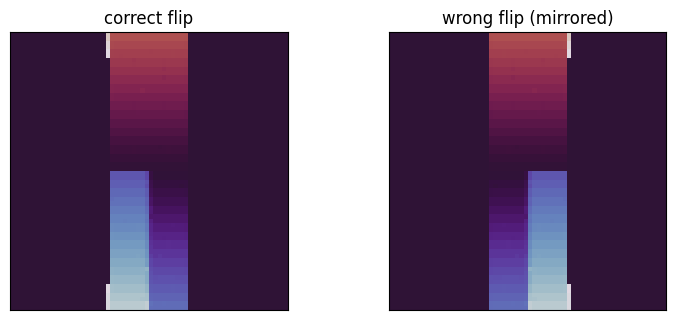

In [7]:
wrong = dict(CFG["detector_flip"]); wrong["fliplr"] = not wrong["fliplr"]
fig, ax = plt.subplots(1, 2, figsize=(8, 3.3))
ax[0].imshow(cs.numpy(), cmap="twilight"); ax[0].set_title("correct flip")
ax[1].imshow(unflip(center_map, wrong).numpy(), cmap="twilight"); ax[1].set_title("wrong flip (mirrored)")
for a in ax: a.set_xticks([]); a.set_yticks([])
plt.tight_layout(); plt.show()

### 4c. Realistic detector noise

The maps above use clean intensity to show the method. Real frames have a thermal pedestal and
Poisson noise (`detector_model`). Two rules for real data: **(1) subtract a background**
(here, each pixel's off-Bragg baseline) so it doesn't bias the peak; **(2) mask or cross-check
low-signal pixels** — `fit_rocking_curve` now bounds the peak centre to the scanned range so it
no longer diverges on noise, but a no-signal pixel still has no meaningful centre, so the robust
centre-of-moment is a good cross-check (the guard in §4 falls back to it).

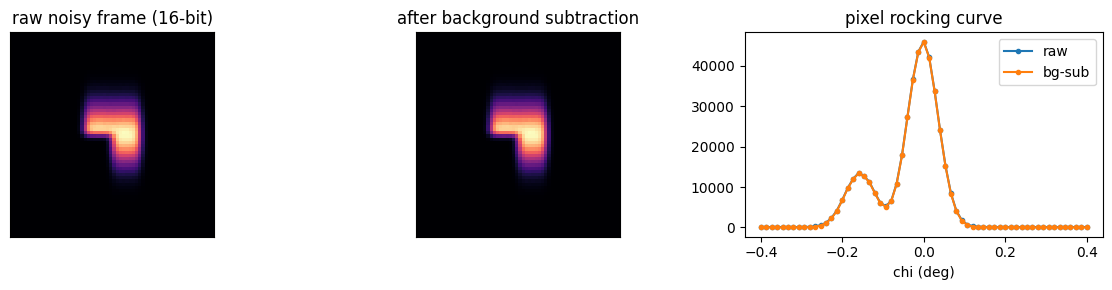

noisy (bg-sub) moment vs clean fit: RMS = 22 mdeg (peak FWHM ~ 61 mdeg; finer steps / more counts tighten this)


In [8]:
gen = torch.Generator().manual_seed(7)
noisy = torch.stack([detector_model(fr, noise=True, generator=gen).to(DT) for fr in clean_1d])
sub   = bg_subtract(noisy)
fig, ax = plt.subplots(1, 3, figsize=(12, 3))
mid = len(ang)//2
ax[0].imshow(noisy[mid].numpy(), cmap="magma");      ax[0].set_title("raw noisy frame (16-bit)")
ax[1].imshow(sub[mid].numpy(),   cmap="magma");      ax[1].set_title("after background subtraction")
ax[2].plot(ang.numpy(), noisy[:,py,px].numpy(), ".-", label="raw"); ax[2].plot(ang.numpy(), sub[:,py,px].numpy(), ".-", label="bg-sub")
ax[2].legend(); ax[2].set_title("pixel rocking curve"); ax[2].set_xlabel("chi (deg)")
for a in ax[:2]: a.set_xticks([]); a.set_yticks([])
plt.tight_layout(); plt.show()

# reconstruct the noisy scan with the robust moment, compare to the clean fit
sub_f = sub.reshape(M,-1).T.clamp_min(0)
mom_noisy = ((sub_f*ang).sum(-1)/(sub_f.sum(-1)+1e-30)).reshape(H,W)
print(f"noisy (bg-sub) moment vs clean fit: RMS = "
      f"{float((mom_noisy-center_map)[lit].pow(2).mean().sqrt())*1000:.0f} mdeg "
      f"(peak FWHM ~ {2.3548*math.degrees(float(res.sigma_perp)/q_mag)*1000:.0f} mdeg; "
      f"finer steps / more counts tighten this)")

## 5. Simulate a 2D rocking scan (mosaicity scan)

Rock **two** axes (`chi`, `phi`) on a grid. Each pixel now has a 2D intensity map over
`(chi, phi)`; its 2D peak is the full local orientation, its 2D spread the mosaic — which for
DFXM is strongly **anisotropic** (tight along *rock*, wide along *roll*).

2D stack: (289, 64, 64) over 289 settings


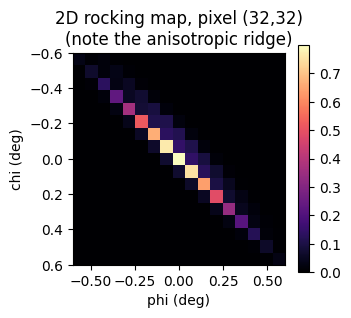

In [9]:
s2 = mosaicity_scan(center, chi_range=(-CFG["span_2d"],CFG["span_2d"]),
                    phi_range=(-CFG["span_2d"],CFG["span_2d"]), n_chi=CFG["n_2d"], n_phi=CFG["n_2d"])
chi = scan_angles(s2,"chi"); phi = scan_angles(s2,"phi")
clean_2d = dfxm_stack(field, CFG["hkl"], s2, res, optics)
if CFG["add_noise"]:
    g = torch.Generator().manual_seed(2)
    obs_2d = bg_subtract(torch.stack([detector_model(fr, noise=True, generator=g).to(DT) for fr in clean_2d]))
else:
    obs_2d = clean_2d
obs_2d = apply_detector_flip(obs_2d, CFG["detector_flip"])
print("2D stack:", tuple(obs_2d.shape), "over", len(chi), "settings")
n = CFG["n_2d"]; py, px = obs_2d.shape[1]//2, obs_2d.shape[2]//2
plt.figure(figsize=(3.6,3.2)); plt.imshow(obs_2d[:,py,px].reshape(n,n).numpy(), cmap="magma",
    extent=[phi.min(),phi.max(),chi.max(),chi.min()])
plt.xlabel("phi (deg)"); plt.ylabel("chi (deg)"); plt.title(f"2D rocking map, pixel ({py},{px})\n(note the anisotropic ridge)")
plt.colorbar(); plt.tight_layout(); plt.show()

## 6. Reconstruct the 2D scan

**Orientation** — `moment_orientation` gives the per-pixel centre-of-mass in `(chi, phi)`: robust
and exact (it tracks the 2D peak to a few mdeg).

**Resolution & mosaic** — the instrument acceptance is measured the way you would on the
beamline: run the *same scan on a near-perfect crystal* and take its 2D second-moment covariance
as `res_cov`. Deconvolving it from the sample's per-pixel covariance leaves the **intrinsic
mosaic**. The perfect-crystal covariance is a thin ellipse — **rock ≪ roll** — the Poulsen
anisotropy.

> `midas_dfxm.fit_orientation_mosaicity` offers a joint Gaussian-mixture fit that also
> deconvolves the resolution and resolves sub-grains (multiple components per pixel). We show
> the transparent moment + calibrated-`res_cov` route here because it is easy to reason about;
> the fit is the tool to reach for when you need the intrinsic mosaic covariance or >1 component,
> and it agrees with the moment on the peak position to a few mdeg.

res_cov eigen-FWHM: rock=0.055 deg  roll=0.741 deg  (rock << roll)
mean intrinsic mosaic FWHM = 0.050 deg (small: locally single-orientation)


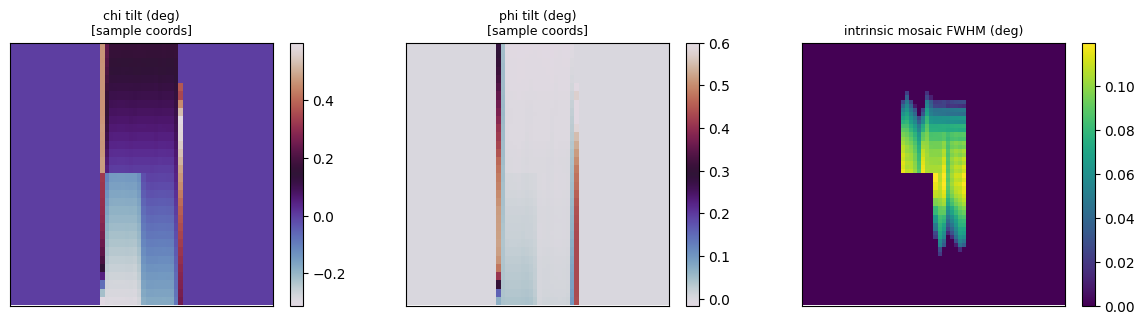

moment vs argmax RMS (chi,phi) = (25.8, 18.0) mdeg


In [10]:
def rocking_cov(data, chi, phi, com):
    w = data.clamp_min(0); ws = w.sum(-1, keepdim=True) + 1e-30
    dc = chi[None,:]-com[:,0:1]; dp = phi[None,:]-com[:,1:2]
    return torch.stack([(w*dc*dc).sum(-1), (w*dc*dp).sum(-1), (w*dp*dp).sum(-1)], -1)/ws   # c00,c01,c11

# --- calibrate res_cov on a near-perfect crystal (same scan) ---
perfect = make_uniform_field(shape=CFG["slab_shape"], spacing_um=CFG["voxel_um"],
                             lattice_params=CFG["lattice"], dtype=DT)
dperf = dfxm_stack(perfect, CFG["hkl"], s2, res, optics).reshape(len(chi),-1).T.contiguous()
lp = dperf.sum(-1) > 0.05*dperf.max()
res_cov3 = rocking_cov(dperf, chi, phi, moment_orientation(dperf,chi,phi))[lp].mean(0)
Rc = torch.tensor([[res_cov3[0],res_cov3[1]],[res_cov3[1],res_cov3[2]]])
ev = torch.linalg.eigvalsh(Rc)
print(f"res_cov eigen-FWHM: rock={2.3548*float(ev[0])**0.5:.3f} deg  roll={2.3548*float(ev[1])**0.5:.3f} deg  (rock << roll)")

# --- reconstruct the sample ---
M2, H, W = obs_2d.shape
data_2d = obs_2d.reshape(M2,-1).T.contiguous()
ori = moment_orientation(data_2d, chi, phi)                       # (P,2)
lit2 = data_2d.sum(-1).reshape(H,W) > 0.05*obs_2d.max()
cov  = rocking_cov(data_2d, chi, phi, ori)
intr = torch.clamp(0.5*(cov[:,0]+cov[:,2]) - 0.5*(res_cov3[0]+res_cov3[2]), min=0)   # intrinsic scalar var
print(f"mean intrinsic mosaic FWHM = {2.3548*float(intr[lit2.reshape(-1)].mean())**0.5:.3f} deg (small: locally single-orientation)")

fig, ax = plt.subplots(1, 3, figsize=(12, 3.3))
for k,(name,comp) in enumerate([("chi tilt (deg)",ori[:,0]),("phi tilt (deg)",ori[:,1])]):
    c=ax[k].imshow(unflip(comp.reshape(H,W),CFG['detector_flip']).numpy(), cmap="twilight")
    ax[k].set_title(name+"\n[sample coords]",fontsize=9); plt.colorbar(c,ax=ax[k],fraction=.046); ax[k].set_xticks([]); ax[k].set_yticks([])
c=ax[2].imshow(unflip((2.3548*intr.reshape(H,W).clamp_min(0)**0.5),CFG['detector_flip']).numpy(), cmap="viridis")
ax[2].set_title("intrinsic mosaic FWHM (deg)",fontsize=9); plt.colorbar(c,ax=ax[2],fraction=.046); ax[2].set_xticks([]); ax[2].set_yticks([])
plt.tight_layout(); plt.show()

# validate orientation vs argmax (both robust peak locators)
am = data_2d.argmax(-1); arg = torch.stack([chi[am],phi[am]],-1)
print("moment vs argmax RMS (chi,phi) =",
      tuple(round(float((ori-arg)[lit2.reshape(-1)][:,i].pow(2).mean().sqrt())*1000,1) for i in (0,1)), "mdeg")

## 7. Convention & flip robustness

Two checks you can run on any real set: (1) switch the scattering plane and watch the rock axis
and detector basis change — the reconstruction code is identical, only the geometry object
differs; (2) find the **map orientation** (flip/transpose) that best aligns your reconstructed
map to a known reference (here the ground truth; on real data, a fiducial or a coarse
independent map). Note this recovers the *total* sample→map orientation, which folds in **both**
the detector flip **and** the intrinsic sample→detector projection handedness (`v ∝ −sin2θ·x`,
so the imaged x-axis is mirrored) — so the winning flip need not equal the configured
`detector_flip`; it is the transform that makes your map match the world.

In [11]:
for plane in ("vertical","horizontal"):
    g = ScatteringGeometry(frame=FRAME, plane=plane)
    print(f"{plane:10s}: rock axis {tuple(round(float(x),2) for x in g.plane_normal())}  "
          f"deflection {tuple(round(x,2) for x in g.deflection)}")

gt_small = torch.nn.functional.interpolate(gt_tilt_deg(field).reshape(1,1,ny,nx).to(DT),
             size=(H,W), mode="bilinear", align_corners=False)[0,0]
best=None
for fl in [dict(fliplr=a,flipud=b,transpose=c) for a in (0,1) for b in (0,1) for c in (0,1)]:
    cand = unflip(center_map, fl)
    cc = float(torch.corrcoef(torch.stack([cand[lit], gt_small[lit]]))[0,1])
    if best is None or abs(cc)>abs(best[1]): best=(fl,cc)
print("map orientation best aligning to ground truth:", best[0], " |corr| =", round(abs(best[1]),3))
print("configured detector_flip:", CFG["detector_flip"], "  (difference = projection handedness)")

vertical  : rock axis (0.0, -1.0, 0.0)  deflection (0.0, 0.0, 1.0)
horizontal: rock axis (0.0, 0.0, 1.0)  deflection (0.0, 1.0, 0.0)
map orientation best aligning to ground truth: {'fliplr': 1, 'flipud': 0, 'transpose': 0}  |corr| = 0.674
configured detector_flip: {'fliplr': False, 'flipud': False, 'transpose': False}   (difference = projection handedness)


## 7b. Reduce YOUR OWN scan — strain or mosaic, real frames

Everything above is simulated so the method is visible. This section runs the **same
per-pixel moment reduction on real detector frames** you point it at, and **auto-classifies the
scan from the motor log** (per §1a):

- **mosaic scan** (a tilt rocked at *fixed* `2θ`): per-pixel peak → **lattice tilt** (mdeg).
- **strain scan** (`θ` and `2θ` coupled, `d(2θ)/dθ ≈ 2`): per-pixel peak → **relative strain**
  `ε = −cotθ_B·Δθ` (refraction stays in the reference).

**Identify the sweep from the motor log, not the filename.** Point `MOTORINFO` at the
`*_motorInfo.csv` for the scan; the loader reads the real `two-theta` and `theta` columns and
decides mosaic (2θ fixed) vs strain (2θ moves). *This matters:* on the NaMnO2 6-ID-C data the
**filenames** encode a coupled pair that looks like a θ–2θ strain scan, but the **motor log**
shows `2θ` held fixed at 22.874 while only `θ` rocked — a **mosaic scan** — and the filename
θ-step was *half* the true motor step. Trusting the filename would have mis-typed the scan and
halved the tilt scale. **Always read the motor log.** (6-ID-C → `geometry="HORIZONTAL_APS"`.)

Real frames also need three things the simulated demo skipped — the reducer does all of them and
prints the result: **(1)** subtract the per-pixel pedestal *before* the first moment (a raw
centroid is pedestal-dominated); **(2)** width from the **contiguous half-max**, not a second
moment (which is inflated by tails); **(3) validity + accuracy checks** — frame registration
(no drift), the single-peak fraction (a translating-blob gives a false map and fails this), a
**split-half** per-pixel accuracy (an even/odd split, *not* a self-resample), and the fraction
of the map that is just a planar ramp. Treat the peak-position map as the trustworthy output;
the amplitude carries a bulk scale caveat (see the printed notes).

In [12]:
import glob, re
import os as _os
DATA_DIR   = None            # e.g. "/path/to/NaMnO2/S006"  -> set this to your frame folder
MOTORINFO  = None            # path to <scan>_motorInfo.csv (AUTHORITATIVE angles); None = try filename
FRAME_SORT_REGEX = r"_([0-9.]+)_"   # a per-filename number to sort frames into scan order
ROI        = None            # (r0,r1,c0,c1) crop to the sample, or None for the full frame

def load_scan(folder, motorinfo=None, sort_regex=FRAME_SORT_REGEX):
    '''ALWAYS prefer the motor log for angles (rule 10: filenames can be a misleading
    encoding -- on the NaMnO2 6-ID-C data the filenames looked like a theta-2theta strain
    scan, but motorInfo showed 2theta fixed + theta rocking = a MOSAIC scan). classify from
    whether 2theta moves.'''
    import tifffile
    fs = sorted(glob.glob(f"{folder}/*.tif") + glob.glob(f"{folder}/*.tiff"),
                key=lambda f: float(re.search(sort_regex, _os.path.basename(f)).group(1)))
    stack = np.stack([tifffile.imread(f).astype(np.float32) for f in fs])
    if motorinfo and _os.path.isfile(motorinfo):
        import pandas as pd
        df = pd.read_csv(motorinfo)
        thu = np.unique(np.round(pd.to_numeric(df["theta"], errors="coerce").astype(float), 4))
        tt = pd.to_numeric(df["two-theta"], errors="coerce").astype(float).values
        stype = "mosaic" if np.ptp(tt) < 1e-4 else "strain"
        theta = thu if len(thu) == len(fs) else np.interp(np.linspace(0,1,len(fs)), np.linspace(0,1,len(thu)), thu)
        return stack, theta, stype, float(tt[0])
    # fallback: two angle numbers from the filename (LESS RELIABLE)
    a = lambda f: [float(x) for x in re.findall(r"_([0-9.]+)_([0-9.]+)_", _os.path.basename(f))[0]]
    coupled = np.array([a(f)[0] for f in fs]); theta = np.array([a(f)[1] for f in fs])
    slope = np.polyfit(theta, coupled, 1)[0]
    return stack, theta, ("strain" if abs(slope-2) < 0.3 else "mosaic"), slope

def reduce_real(stack, theta, stype, roi=None, ped_pct=25.0, lit_pct=80.0):
    if roi is not None: stack = stack[:, roi[0]:roi[1], roi[2]:roi[3]]
    sub = np.clip(stack - np.percentile(stack, ped_pct, 0)[None], 0, None)   # pedestal off (rule 1)
    integ = sub.sum(0); lit = integ > np.percentile(integ, lit_pct)
    thc = (sub*theta[:,None,None]).sum(0) / (sub.sum(0)+1e-9)                # per-pixel peak theta
    thref = float(np.median(thc[lit]))
    if stype == "strain":
        cot = 1.0/np.tan(np.radians(np.median(theta)))
        sig = -cot*np.radians(thc-thref)*1e6; lab = "relative strain (ue)"
    else:
        sig = (thc-thref)*1000.0; lab = "lattice tilt (mdeg)"
    return integ, lit, np.where(lit, sig, np.nan), lab

if DATA_DIR and _os.path.isdir(DATA_DIR):
    stack, theta, stype, aux = load_scan(DATA_DIR, MOTORINFO)
    print(f"{len(theta)} frames, theta {theta.min():.3f}-{theta.max():.3f} deg "
          f"({np.median(np.diff(theta))*1000:.1f} mdeg step) -> {stype.upper()} scan "
          f"({'2theta fixed '+format(aux,'.3f') if stype=='mosaic' and MOTORINFO else 'slope '+format(aux,'.2f')})")
    integ, lit, sigmap, lab = reduce_real(stack, theta, stype, roi=ROI)
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    im=ax[0].imshow(integ, cmap="magma", vmax=np.percentile(integ,99.5)); ax[0].set_title("integrated (bg-sub)"); plt.colorbar(im,ax=ax[0],fraction=.046)
    im=ax[1].imshow(sigmap, cmap="RdBu_r", vmin=np.nanpercentile(sigmap,2), vmax=np.nanpercentile(sigmap,98)); ax[1].set_title(lab); plt.colorbar(im,ax=ax[1],fraction=.046)
    for a in ax: a.set_xticks([]); a.set_yticks([])
    plt.tight_layout(); plt.show()
else:
    print("Set DATA_DIR to a folder of DFXM frames and ANGLE_REGEX to read each frame's angle,")
    print("then re-run this cell. It auto-detects strain (theta-2theta) vs mosaic (theta-rock).")
    print("A fuller reducer (contiguous-half-max width + injection-recovery) is in the analysis")
    print("script namno2_reduce.py; this cell is the minimal in-notebook version.")

Set DATA_DIR to a folder of DFXM frames and ANGLE_REGEX to read each frame's angle,
then re-run this cell. It auto-detects strain (theta-2theta) vs mosaic (theta-rock).
A fuller reducer (contiguous-half-max width + injection-recovery) is in the analysis
script namno2_reduce.py; this cell is the minimal in-notebook version.


## 8. From simulation to real data — checklist

1. **Fix the convention first.** Set `geometry_plane` + `lab_frame` to your beamline (ESRF ID06 →
   `"vertical"/"midas"`; APS 6-ID-C transmission → `"horizontal"`). Rock axis, detector basis, and
   resolution roles follow automatically.
2. **Find the detector flip** with a fiducial (Section 7). A wrong flip silently mirrors your map.
3. **Calibrate `res_cov` on a near-perfect crystal** (its rocking covariance *is* the instrument
   acceptance — thin, rock ≪ roll). Deconvolve it so the reported mosaic is intrinsic.
4. **1D vs 2D.** One rock axis → one tilt component + a 1D width (`fit_rocking_curve`). Two axes →
   full orientation (`moment_orientation`) + the anisotropic mosaic covariance.
5. **Orientation vs strain.** A rocking set gives orientation/mosaic. **Strain** (d-spacing) needs
   the longitudinal θ–2θ channel — a separate strain scan. See the `dfxm` skill for the full
   orientation+strain pipeline.

**Functions used:** `ScatteringGeometry`/`LabFrame` · `make_uniform_field`,
`with_orientation_gradient` · `rocking_scan`, `mosaicity_scan`, `scan_angles`, `dfxm_stack`,
`detector_model` · `fit_rocking_curve` (1D) · `moment_orientation` (2D). All in `midas_dfxm`.
